In [7]:
import matplotlib.pyplot as plt
import plotly.express as pltexp
import seaborn as sns
import pandas as pd
# from sklearn.preprocessing import LabelEncoder
# labeller = LabelEncoder()

In [8]:
df = pd.read_csv(r"C:\Users\bunyo\OneDrive\Desktop\kaggleDataSet\House Price Prediction Dataset.csv")

In [13]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [14]:
x = df['Floors']
y = df['Bedrooms']

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.xlabel('wwww')
plt.plot(x,y,'b')

plt.subplot(1,2,2)
plt.plot(y,x,'r')

In [ ]:
fig = plt.figure()

axes = fig.add_axes([1,1,1,1])
axes.plot(x,y)

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,10))
axes[0].plot(x,y)
axes[1].plot(y,x,'r')

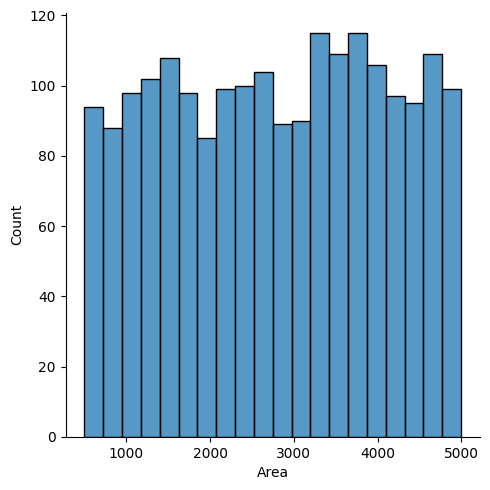

In [53]:
sns.displot(df['Area'],bins=20)

In [ ]:
sns.pairplot(df,hue='Location')

<Axes: xlabel='Area', ylabel='Price'>

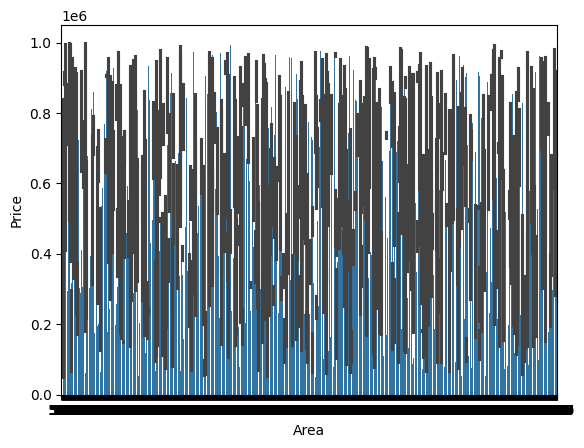

In [63]:
sns.barplot(data=df,x = 'Area',y='Price')

<Axes: xlabel='Location', ylabel='count'>

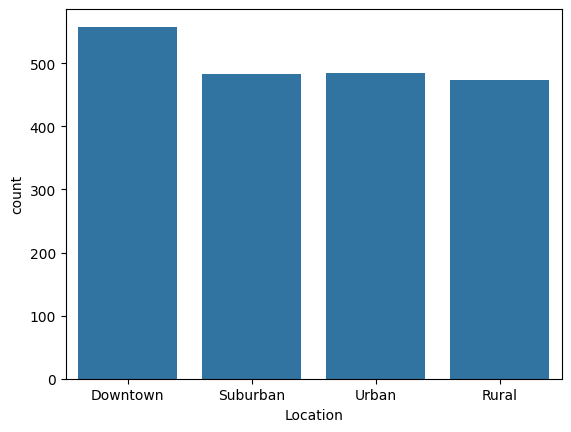

In [62]:
sns.countplot(x='Location',data=df)

<Figure size 640x480 with 0 Axes>

In [ ]:
import klib

In [3]:
df = pd.read_csv(r"C:\Users\bunyo\OneDrive\Desktop\git_dataset\healthcare_dataset.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [5]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [6]:
klib.missingval_plot(df)

No missing values found in the dataset.


In [13]:
plt.figure(figsize=(8,6))
klib.corr_interactive_plot(df)

<Figure size 800x600 with 0 Axes>

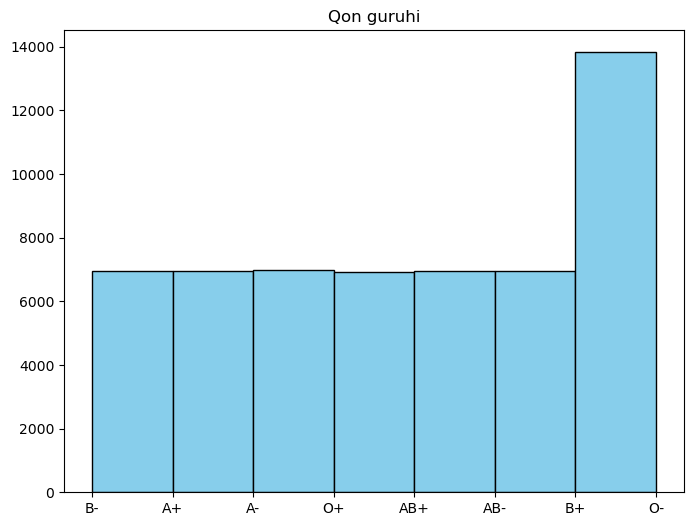

In [12]:
plt.figure(figsize=(8,6))
plt.hist(df['Blood Type'],bins=7,color='skyblue',edgecolor='black')
plt.title('Qon guruhi')
plt.show()

In [14]:
def tozalovchi(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype=='object':
                df[col].fillna(df[col].mode()[0],inplace=True)
            else:
                df[col].fillna(df[col].mean(),inplace=True)
    return df

In [15]:
df = tozalovchi(df)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [17]:
def encodla(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            if df[col].nunique() <= 4:
                dummies=pd.get_dummies(df[col],prefix=col,dtype=int)
                df=pd.concat([df.drop(columns=col),dummies],axis=1)
            else:
                df[col]=labeller.fit_transform(df[col])
    return df


In [20]:
df = encodla(df)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       55500 non-null  int64  
 1   Age                        55500 non-null  int64  
 2   Blood Type                 55500 non-null  int64  
 3   Medical Condition          55500 non-null  int64  
 4   Date of Admission          55500 non-null  int64  
 5   Doctor                     55500 non-null  int64  
 6   Hospital                   55500 non-null  int64  
 7   Insurance Provider         55500 non-null  int64  
 8   Billing Amount             55500 non-null  float64
 9   Room Number                55500 non-null  int64  
 10  Discharge Date             55500 non-null  int64  
 11  Medication                 55500 non-null  int64  
 12  Gender_Female              55500 non-null  int64  
 13  Gender_Male                55500 non-null  int

# Random forrest

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
DT_class = DecisionTreeClassifier()

In [29]:
x = df.drop('Medical Condition', axis=1)
y = df['Medical Condition']

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=45)

In [32]:
DT_class.fit(x_train,y_train)

DecisionTreeClassifier()

In [34]:
pred1 = DT_class.predict(x_test)

In [35]:
print(classification_report(y_test,pred1))

              precision    recall  f1-score   support

           0       0.27      0.26      0.27      2837
           1       0.28      0.28      0.28      2802
           2       0.26      0.27      0.27      2762
           3       0.27      0.27      0.27      2794
           4       0.27      0.27      0.27      2751
           5       0.26      0.27      0.27      2704

    accuracy                           0.27     16650
   macro avg       0.27      0.27      0.27     16650
weighted avg       0.27      0.27      0.27     16650



# Data Cleaner bilan bajarish

In [ ]:
 df1 = pd.read_csv(r"C:\Users\bunyo\OneDrive\Desktop\git_dataset\healthcare_dataset.csv")

In [51]:
df1=klib.data_cleaning(df1, drop_duplicates=True)

Shape of cleaned data: (54966, 15) - Remaining NAs: 0


Dropped rows: 534
     of which 534 duplicates. (Rows (first 150 shown): [50023, 50040, 50055, 50070, 50078, 50081, 50086, 50090, 50095, 50102, 50103, 50116, 50120, 50124, 50137, 50147, 50151, 50159, 50171, 50180, 50182, 50187, 50190, 50216, 50226, 50242, 50247, 50253, 50272, 50312, 50314, 50320, 50325, 50337, 50347, 50350, 50353, 50362, 50366, 50370, 50373, 50391, 50445, 50463, 50469, 50477, 50478, 50489, 50521, 50522, 50524, 50525, 50532, 50551, 50559, 50567, 50596, 50602, 50603, 50604, 50611, 50623, 50624, 50625, 50629, 50645, 50660, 50684, 50699, 50710, 50719, 50723, 50731, 50743, 50749, 50755, 50760, 50765, 50766, 50782, 50786, 50789, 50795, 50802, 50830, 50848, 50871, 50914, 50919, 50924, 50948, 50958, 50965, 50973, 50983, 50985, 50996, 51005, 51016, 51023, 51028, 51036, 51044, 51059, 51067, 51069, 51075, 51091, 51098, 51121, 51122, 51124, 51125, 51135, 51137, 51146, 51158, 51161, 51173, 51180, 51185, 51192, 51200, 51229, 51

In [52]:
from datacleaner import autoclean

In [53]:
df1 = autoclean(df1)

c:\Users\bunyo\anaconda3\Lib\site-packages\datacleaner\datacleaner.py:77: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



c:\Users\bunyo\anaconda3\Lib\site-packages\datacleaner\datacleaner.py:77: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [55]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   name                54966 non-null  string  
 1   age                 54966 non-null  int8    
 2   gender              54966 non-null  category
 3   blood_type          54966 non-null  category
 4   medical_condition   54966 non-null  category
 5   date_of_admission   54966 non-null  string  
 6   doctor              54966 non-null  string  
 7   hospital            54966 non-null  string  
 8   insurance_provider  54966 non-null  category
 9   billing_amount      54966 non-null  float64 
 10  room_number         54966 non-null  int16   
 11  admission_type      54966 non-null  category
 12  discharge_date      54966 non-null  string  
 13  medication          54966 non-null  category
 14  test_results        54966 non-null  category
dtypes: category(7), float64(1), int16(1)

In [56]:
x = df1.drop('medical_condition', axis=1)
y = df1['medical_condition']


In [57]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=45)

In [58]:
DT_class1 = DecisionTreeClassifier()

In [ ]:
DT_class1.fit(x_train,y_train)

In [44]:
pred2 = DT_class1.predict(x_test)

In [45]:
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           0       0.27      0.26      0.26      2837
           1       0.28      0.27      0.28      2802
           2       0.26      0.26      0.26      2762
           3       0.27      0.27      0.27      2794
           4       0.27      0.28      0.27      2751
           5       0.27      0.28      0.27      2704

    accuracy                           0.27     16650
   macro avg       0.27      0.27      0.27     16650
weighted avg       0.27      0.27      0.27     16650



In [1]:
class Information:
    def __init__(self,ism,familya,manzil):
        self.ism = ism
        self.familya = familya
        self.manzil = manzil
        
    def tanishtir(self):
        ss = f"Men ismim {self.ism}, va familya {self.familya}, {self.manzil}da yashayman"
        return ss
    
    
    def info(self):
        return f"Men {self.ism}, va {self.manzil}da turamna"
    

In [2]:
qq = Information('Bunyod','Polatov', 'suwon')

In [7]:
print(qq.tanishtir())
print(qq.info())

Men ismim Bunyod, va familya Polatov, suwonda yashayman
Men Bunyod, va suwonda turamna
